<a href="https://colab.research.google.com/github/Gauravvwagle/EasyEat/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split


# 1. Load the dataset
df = pd.read_csv('/content/Malbehave.csv')

# 2. Preprocessing: Drop unique identifiers and empty columns
# 'sha256' is a hash, not a feature for ML.
# We also drop the "Unnamed" columns to clean the feature set.
cols_to_drop = ['sha256', 'labels'] + [c for c in df.columns if 'Unnamed' in c]

X = df.drop(columns=cols_to_drop)
y = df['labels']  # This is your target column

# 3. 70-30 Data Segmentation
# Stratify ensures your 30% test set has the same Malware/Benign ratio as the 70% train set.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Data Segmented Successfully:")
print(f"Features (X) shape: {X_train.shape}") # Should show ~1750 samples and ~153 features
print(f"Labels (y) distribution:\n{y_train.value_counts(normalize=True)}")

Data Segmented Successfully:
Features (X) shape: (1799, 153)
Labels (y) distribution:
labels
1    0.500278
0    0.499722
Name: proportion, dtype: float64


In [ ]:
print(df.columns.tolist())

['sha256', 'labels', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '150', '151', '152', 'Unnamed: 155', 'U

In [ ]:
from sklearn.preprocessing import LabelEncoder

# 1. Identify and encode string columns
# We create a dictionary to store encoders if we need to reverse the process later
encoders = {}
X_encoded = X.copy()

for col in X_encoded.columns:
    if X_encoded[col].dtype == 'object':
        le = LabelEncoder()
        # Ensure all data is treated as string to avoid mixed-type errors
        X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
        encoders[col] = le

# 2. Re-split the now-encoded data
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.30, random_state=42, stratify=y
)

print("Categorical features encoded and data re-segmented.")

Categorical features encoded and data re-segmented.



--- Random Forest Performance ---
Accuracy:  0.9066
Precision: 0.9815
Recall:    0.8286
F1-Score:  0.8986


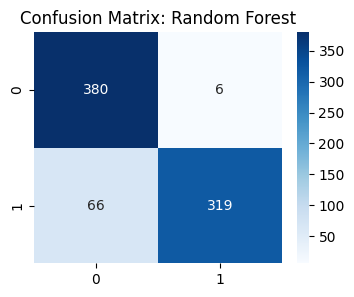


--- XGBoost Performance ---
Accuracy:  0.8962
Precision: 0.9248
Recall:    0.8623
F1-Score:  0.8925


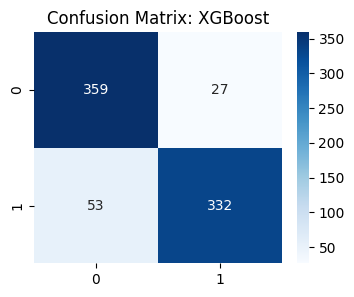

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Define evaluation function
def run_evaluation(model, name):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    print(f"\n--- {name} Performance ---")
    print(f"Accuracy:  {accuracy_score(y_test, preds):.4f}")
    print(f"Precision: {precision_score(y_test, preds):.4f}")
    print(f"Recall:    {recall_score(y_test, preds):.4f}")
    print(f"F1-Score:  {f1_score(y_test, preds):.4f}")

    # Confusion Matrix
    plt.figure(figsize=(4,3))
    sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.show()

# Execute both baseline models
run_evaluation(RandomForestClassifier(n_estimators=100, random_state=42), "Random Forest")
run_evaluation(XGBClassifier(n_estimators=100, random_state=42), "XGBoost")

In [ ]:
# ==========================================
# STEP 1: LOAD DATA
# ==========================================
from google.colab import files
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Upload CSV
uploaded = files.upload()
file_path = list(uploaded.keys())[0]
df = pd.read_csv(file_path)

print(f"Dataset Loaded: {df.shape[0]} samples, {df.shape[1]} features")

# ==========================================
# STEP 2: PREPROCESSING & CLEANING
# ==========================================
# 1. Automatic target identification (handles 'legitimate' or 'labels')
target_col = 'legitimate' if 'legitimate' in df.columns else 'labels'

# 2. Drop unique identifiers (unpredictive hashes/IDs)
cols_to_drop = ['sha256', 'Name', 'md5', 'hash'] # Common ID columns
X = df.drop(columns=[c for c in cols_to_drop if c in df.columns] + [target_col])
y = df[target_col]

# 3. Handle Missing Values (Crucial for Random Forest)
if X.isnull().values.any():
    print("Missing values detected. Filling with 0...")
    X = X.fillna(0)

# 4. Encode Categorical Features
for col in X.select_dtypes(include=['object', 'category']).columns:
    X[col] = X[col].astype('category').cat.codes

# ==========================================
# STEP 3: TRAIN-TEST SPLIT (80/20)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ==========================================
# STEP 4: MODEL TRAINING & EVALUATION
# ==========================================
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\n--- PERFORMANCE SUMMARY ---")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ==========================================
# STEP 5: INTERACTIVE VISUALIZATIONS
# ==========================================

# 5a: Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
# Dynamically assign labels based on target values
unique_labels = sorted(y.unique())
labels_text = ["Malware" if val == 0 else "Legitimate" for val in unique_labels]

fig_cm = px.imshow(cm,
                   text_auto=True,
                   x=labels_text,
                   y=labels_text,
                   color_continuous_scale='Blues',
                   title="Confusion Matrix: Malware vs Legitimate")
fig_cm.update_layout(xaxis_title="Predicted", yaxis_title="Actual")
fig_cm.show()

# 5b: Feature Importance (Top 15)
importances = model.feature_importances_
feat_df = pd.DataFrame({"Feature": X.columns, "Importance": importances})
feat_df = feat_df.sort_values(by="Importance", ascending=False).head(15)

fig_feat = px.bar(feat_df,
                  x="Importance",
                  y="Feature",
                  orientation='h',
                  color="Importance",
                  color_continuous_scale='Viridis',
                  title="Top 15 Malware Indicators (Feature Importance)")
fig_feat.update_layout(yaxis={'categoryorder':'total ascending'})
fig_feat.show()

# 5c: Data Balance Visualization
counts = y.value_counts().reset_index()
counts.columns = ['Status', 'Count']
counts['Status'] = counts['Status'].map({0: 'Malware', 1: 'Legitimate'})

fig_pie = px.pie(counts, values='Count', names='Status',
                 color='Status',
                 color_discrete_map={'Malware': '#EF553B', 'Legitimate': '#636EFA'},
                 title="Dataset Distribution")
fig_pie.show()

Saving Malbehave.csv to Malbehave (2).csv
Dataset Loaded: 2570 samples, 177 features
Missing values detected. Filling with 0...

--- PERFORMANCE SUMMARY ---
Overall Accuracy: 0.9125

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.99      0.92       257
           1       0.99      0.83      0.90       257

    accuracy                           0.91       514
   macro avg       0.92      0.91      0.91       514
weighted avg       0.92      0.91      0.91       514



In [ ]:
# ==========================================
# STEP 1: INSTALL & IMPORT LIBRARIES
# ==========================================
# !pip install xgboost  # Ensure xgboost is installed (it usually is in Colab)

from google.colab import files
import pandas as pd
import numpy as np
import plotly.express as px
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Upload CSV
uploaded = files.upload()
file_path = list(uploaded.keys())[0]
df = pd.read_csv(file_path)

# ==========================================
# STEP 2: PREPROCESSING & CLEANING
# ==========================================
# 1. Dynamic target selection
target_col = 'legitimate' if 'legitimate' in df.columns else 'labels'

# 2. Drop unique identifiers and non-numeric metadata
cols_to_drop = ['sha256', 'Name', 'md5', 'hash', 'MachineIdentifier']
X = df.drop(columns=[c for c in cols_to_drop if c in df.columns] + [target_col])
y = df[target_col]

# 3. Handle Missing Values
X = X.fillna(0)

# 4. Handle Categorical Features (XGBoost requires numbers)
for col in X.select_dtypes(include=['object', 'category']).columns:
    X[col] = X[col].astype('category').cat.codes

# ==========================================
# STEP 3: TRAIN-TEST SPLIT
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ==========================================
# STEP 4: TRAIN XGBOOST MODEL
# ==========================================
# We use standard hyperparameters for robust detection
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

print("\n--- XGBOOST PERFORMANCE ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ==========================================
# STEP 5: INTERACTIVE VISUALIZATIONS
# ==========================================

# 5a: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
labels_text = ["Malware" if val == 0 else "Legitimate" for val in sorted(y.unique())]

fig_cm = px.imshow(cm, text_auto=True, x=labels_text, y=labels_text,
                   color_continuous_scale='Reds', # Red theme for XGBoost
                   title="XGBoost Confusion Matrix")
fig_cm.update_layout(xaxis_title="Predicted", yaxis_title="Actual")
fig_cm.show()

# 5b: XGBoost Feature Importance (Gain-based)
# XGBoost calculates importance differently than RF (Gain vs Gini)
importances = model.feature_importances_
feat_df = pd.DataFrame({"Feature": X.columns, "Importance": importances})
feat_df = feat_df.sort_values(by="Importance", ascending=False).head(15)

fig_feat = px.bar(feat_df, x="Importance", y="Feature", orientation='h',
                  color="Importance", color_continuous_scale='Magma',
                  title="Top 15 XGBoost Malware Features (by Gain)")
fig_feat.update_layout(yaxis={'categoryorder':'total ascending'})
fig_feat.show()

Saving Malbehave.csv to Malbehave (3).csv


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[08:41:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.





--- XGBOOST PERFORMANCE ---
Accuracy: 0.9086

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.91       257
           1       0.94      0.87      0.91       257

    accuracy                           0.91       514
   macro avg       0.91      0.91      0.91       514
weighted avg       0.91      0.91      0.91       514



In [ ]:
# ==========================================
# STEP 1: LOAD LIBRARIES & DATA
# ==========================================
from google.colab import files
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Upload and Load
uploaded = files.upload()
file_path = list(uploaded.keys())[0]
df = pd.read_csv(file_path)

# ==========================================
# STEP 2: PREPROCESSING
# ==========================================
target_col = 'legitimate' if 'legitimate' in df.columns else 'labels'
cols_to_drop = ['sha256', 'Name', 'md5', 'hash', 'MachineIdentifier']
X = df.drop(columns=[c for c in cols_to_drop if c in df.columns] + [target_col])
y = df[target_col]

X = X.fillna(0) # Handle missing values

# Encode categorical features
for col in X.select_dtypes(include=['object', 'category']).columns:
    X[col] = X[col].astype('category').cat.codes

# 80/20 Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ==========================================
# STEP 3: MODEL EXECUTION ENGINE
# ==========================================
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, eval_metric='logloss', random_state=42)
}

results = []

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    # Predict
    preds = model.predict(X_test)

    # Calculate Metrics
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

    # Confusion Matrix Visualization
    cm = confusion_matrix(y_test, preds)
    labels_text = ["Malware", "Legitimate"]
    fig_cm = px.imshow(cm, text_auto=True, x=labels_text, y=labels_text,
                       color_continuous_scale='Blues' if name == "Random Forest" else 'Reds',
                       title=f"Confusion Matrix: {name}")
    fig_cm.show()

# ==========================================
# STEP 4: FINAL COMPARISON & METRICS
# ==========================================
results_df = pd.DataFrame(results)
print("\n--- FINAL MODEL COMPARISON ---")
print(results_df.to_string(index=False))

# Comparative Bar Chart
fig_compare = go.Figure()
for metric in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    fig_compare.add_trace(go.Bar(
        x=results_df["Model"],
        y=results_df[metric],
        name=metric,
        text=results_df[metric].round(4),
        textposition='auto'
    ))

fig_compare.update_layout(title="Model Comparison: RF vs XGBoost", barmode='group', yaxis_range=[0, 1.1])
fig_compare.show()

Saving Malbehave.csv to Malbehave (1).csv



--- FINAL MODEL COMPARISON ---
        Model  Accuracy  Precision   Recall  F1-Score
Random Forest  0.912451   0.990741 0.832685  0.904863
      XGBoost  0.908560   0.941176 0.871595  0.905051


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install torch torchvision torchaudio
!pip install torch-geometric
!pip install networkx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.6 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn.functional as F
from torch.nn import Linear
from torch_geometric.nn import SAGEConv, global_mean_pool
from torch_geometric.data import Data, DataLoader

import networkx as nx
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
def build_graph(api_string, dll_string):
    G = nx.DiGraph()

    api_list = str(api_string).split()
    dll_list = str(dll_string).split()

    # Add nodes
    for api in api_list:
        G.add_node(api)

    for dll in dll_list:
        G.add_node(dll)

    # Sequential API edges
    for i in range(len(api_list)-1):
        G.add_edge(api_list[i], api_list[i+1])

    # API → DLL edges
    for api in api_list:
        for dll in dll_list:
            G.add_edge(api, dll)

    return G

In [ ]:
def nx_to_pyg(G, label):
    mapping = {node: i for i, node in enumerate(G.nodes())}

    edges = [(mapping[u], mapping[v]) for u,v in G.edges()]

    if len(edges) == 0:
        return None

    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

    x = torch.eye(len(G.nodes()))  # identity features

    data = Data(x=x, edge_index=edge_index)
    data.y = torch.tensor([label], dtype=torch.long)

    return data

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import kneighbors_graph
import torch
from torch_geometric.data import Data
from torch_geometric.utils import to_undirected

# ==============================
# DATA LOADING
# ==============================
from google.colab import files
import pandas as pd
import numpy as np

try:
    uploaded = files.upload()
    file_path = list(uploaded.keys())[0]
except:
    file_path = '/content/Malbehave.csv'

df = pd.read_csv(file_path)

# ==============================
# PREPROCESSING
# ==============================

target_col = 'legitimate' if 'legitimate' in df.columns else 'labels'

cols_to_drop = ['sha256', 'Name', 'md5', 'hash', 'MachineIdentifier']

X = df.drop(columns=[c for c in cols_to_drop if c in df.columns] + [target_col])
y = df[target_col]

# Fill missing values
X = X.fillna(0)

# Encode categorical columns
for col in X.select_dtypes(include=['object', 'category']).columns:
    X[col] = X[col].astype('category').cat.codes

# ==============================
# FEATURE SCALING
# ==============================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==============================
# KNN GRAPH CONSTRUCTION
# ==============================

A = kneighbors_graph(
    X_scaled,
    n_neighbors=5,
    mode='connectivity',
    include_self=False
)

# FAST & CORRECT EDGE CREATION
row, col = A.nonzero()
edge_index = torch.from_numpy(
    np.vstack((row, col)).astype(np.int64)
)

# Make graph undirected (recommended for GraphSAGE)
edge_index = to_undirected(edge_index)

# ==============================
# TENSOR CONVERSION
# ==============================

x_tensor = torch.from_numpy(X_scaled).float()
y_tensor = torch.from_numpy(y.values).long()

# ==============================
# CREATE PyG DATA OBJECT
# ==============================

data = Data(x=x_tensor, edge_index=edge_index, y=y_tensor)

dataset = [data]   # required if using DataLoader

print("Graph Created Successfully")
print(data)

Saving Malbehave.csv to Malbehave (5).csv
Graph Created Successfully
Data(x=[2570, 175], edge_index=[2, 20070], y=[2570])


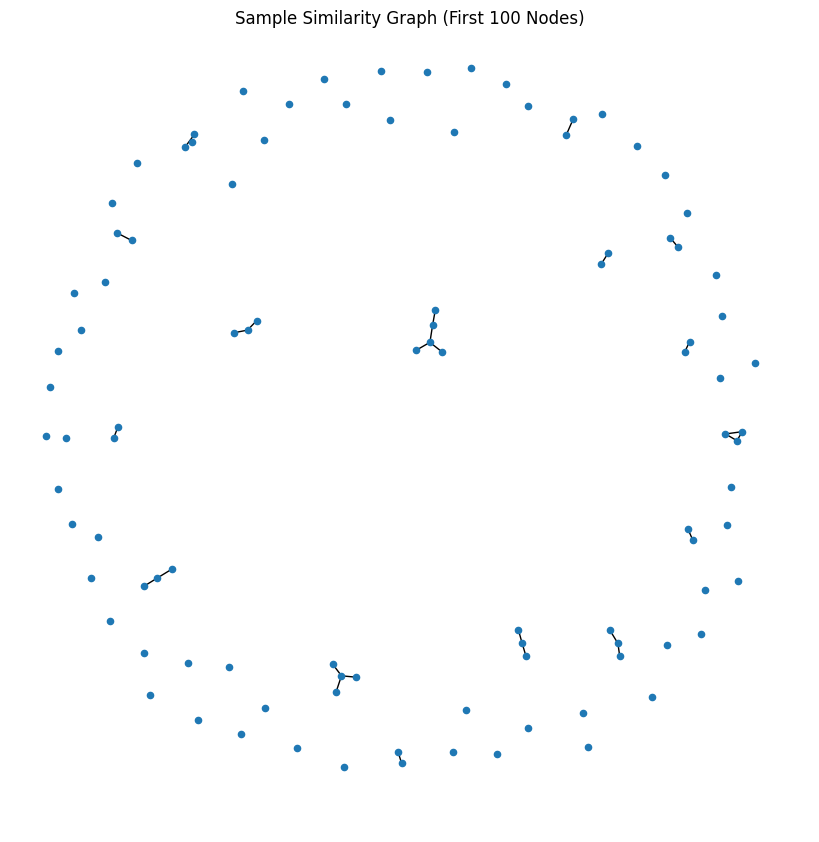

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Convert PyG edge_index to NetworkX
G = nx.Graph()
edges = data.edge_index.t().numpy()
G.add_edges_from(edges)

# ⚠ If dataset is large, draw only first 100 nodes
sub_nodes = list(range(100))
G_sub = G.subgraph(sub_nodes)

plt.figure(figsize=(8,8))
nx.draw(G_sub, node_size=20, with_labels=False)
plt.title("Sample Similarity Graph (First 100 Nodes)")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
import torch

# The error 'ValueError: With n_samples=1, test_size=0.2...' occurs because
# `dataset` is a list containing only one `Data` object ([data]).
# `train_test_split` expects a collection of multiple samples to split.

# For training Graph Neural Networks on a single large graph (like `data` here),
# it's common practice to split the *nodes* of the graph into training and testing sets
# by creating masks, rather than splitting the graph itself.

# 1. Determine the number of nodes in the graph
num_nodes = data.num_nodes

# 2. Calculate the number of nodes for training and testing
train_ratio = 0.8 # As test_size was 0.2, train_size will be 0.8
train_nodes_count = int(num_nodes * train_ratio)

# 3. Create a random permutation of node indices
indices = torch.randperm(num_nodes)

# 4. Create boolean masks directly on the `data` object
data.train_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.test_mask = torch.zeros(num_nodes, dtype=torch.bool)

# Assign nodes to training and testing sets using the masks
data.train_mask[indices[:train_nodes_count]] = True
data.test_mask[indices[train_nodes_count:]] = True

# Printing information about the split for verification
print(f"Node split for a single large graph:")
print(f"Total nodes: {num_nodes}")
print(f"Training nodes: {data.train_mask.sum().item()}")
print(f"Testing nodes: {data.test_mask.sum().item()}")

# With a single large graph, `DataLoader` is typically not used in this manner
# to iterate over `train_dataset` or `test_dataset` when these are just `[data]`.
# Instead, the model is usually trained directly on the `data` object,
# using the `train_mask` to select the nodes for loss calculation.
# Therefore, `train_loader` and `test_loader` are removed from this cell.
# The subsequent training and evaluation cells will need to be adapted
# to use `data.train_mask` and `data.test_mask` directly.


Node split for a single large graph:
Total nodes: 2570
Training nodes: 2056
Testing nodes: 514


In [ ]:
class GraphSAGEModel(torch.nn.Module):
    def __init__(self, input_dim):
        super(GraphSAGEModel, self).__init__()

        self.conv1 = SAGEConv(input_dim, 64)
        self.conv2 = SAGEConv(64, 128)
        self.lin = Linear(128, 2)

    def forward(self, x, edge_index): # Removed 'batch' argument
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))

        # For node-level classification, apply linear layer directly to node embeddings
        x = self.lin(x)

        return F.log_softmax(x, dim=1)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize model with the correct input dimension from the 'data' object
model = GraphSAGEModel(input_dim=data.num_node_features).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses = []

# For a single large graph, we train on the 'data' object directly, using the masks
model.train()
data = data.to(device) # Move the entire graph data to the device once

for epoch in range(100):
    optimizer.zero_grad()

    # Forward pass using the entire graph, then select nodes with train_mask for loss
    # Removed 'data.batch' from model call as it's no longer in the model's forward signature
    out = model(data.x, data.edge_index)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])

    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.7072
Epoch 2, Loss: 0.6749
Epoch 3, Loss: 0.6536
Epoch 4, Loss: 0.6350
Epoch 5, Loss: 0.6164
Epoch 6, Loss: 0.5977
Epoch 7, Loss: 0.5789
Epoch 8, Loss: 0.5600
Epoch 9, Loss: 0.5410
Epoch 10, Loss: 0.5225
Epoch 11, Loss: 0.5056
Epoch 12, Loss: 0.4905
Epoch 13, Loss: 0.4768
Epoch 14, Loss: 0.4642
Epoch 15, Loss: 0.4527
Epoch 16, Loss: 0.4427
Epoch 17, Loss: 0.4339
Epoch 18, Loss: 0.4257
Epoch 19, Loss: 0.4181
Epoch 20, Loss: 0.4110
Epoch 21, Loss: 0.4042
Epoch 22, Loss: 0.3970
Epoch 23, Loss: 0.3897
Epoch 24, Loss: 0.3825
Epoch 25, Loss: 0.3754
Epoch 26, Loss: 0.3682
Epoch 27, Loss: 0.3611
Epoch 28, Loss: 0.3543
Epoch 29, Loss: 0.3473
Epoch 30, Loss: 0.3407
Epoch 31, Loss: 0.3343
Epoch 32, Loss: 0.3280
Epoch 33, Loss: 0.3219
Epoch 34, Loss: 0.3158
Epoch 35, Loss: 0.3098
Epoch 36, Loss: 0.3040
Epoch 37, Loss: 0.2984
Epoch 38, Loss: 0.2930
Epoch 39, Loss: 0.2877
Epoch 40, Loss: 0.2827
Epoch 41, Loss: 0.2777
Epoch 42, Loss: 0.2727
Epoch 43, Loss: 0.2677
Epoch 44, Loss: 0.26

In [ ]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    # Evaluate on the entire graph, then select nodes with test_mask
    data = data.to(device) # Ensure data is on the correct device
    # Removed 'data.batch' from model call as it's no longer in the model's forward signature
    out = model(data.x, data.edge_index)

    # Get predictions for the test nodes only
    pred = out[data.test_mask].argmax(dim=1)

    all_preds.extend(pred.cpu().numpy())
    all_labels.extend(data.y[data.test_mask].cpu().numpy())

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.86      0.89      0.88       255
           1       0.89      0.86      0.88       259

    accuracy                           0.88       514
   macro avg       0.88      0.88      0.88       514
weighted avg       0.88      0.88      0.88       514



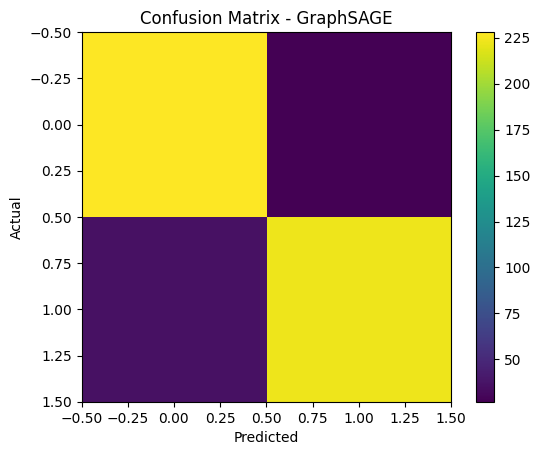

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix - GraphSAGE")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

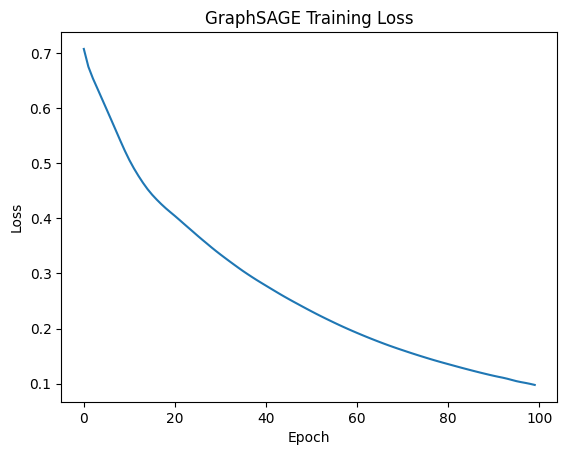

In [ ]:
plt.figure()
plt.plot(train_losses)
plt.title("GraphSAGE Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

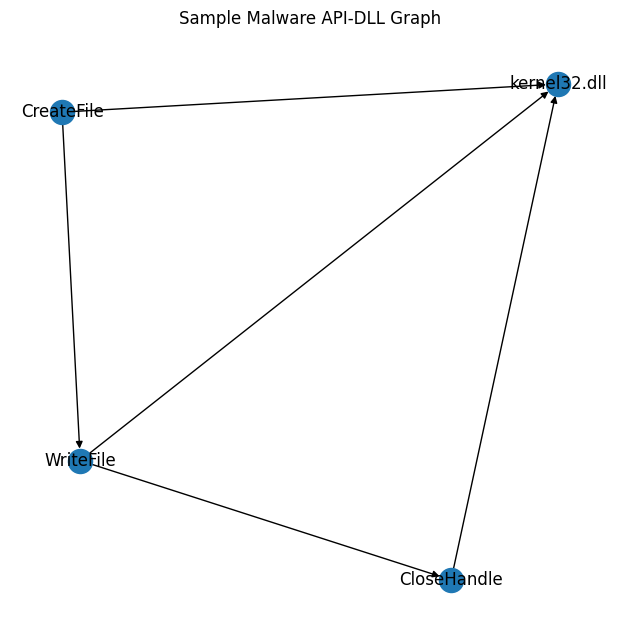

In [ ]:
sample_graph = build_graph("CreateFile WriteFile CloseHandle", "kernel32.dll")

plt.figure(figsize=(6,6))
nx.draw(sample_graph, with_labels=True)
plt.title("Sample Malware API-DLL Graph")
plt.show()